# **Final Notebook: Handcrafted Window Features**

In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.aggregation import aggregate_window_features
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [2]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:04<00:00, 18.81it/s]


In [3]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features:   0%|          | 0/83 [00:00<?, ?it/s]

Extracting Right Features: 100%|██████████| 83/83 [01:41<00:00,  1.22s/it]


In [4]:
extractor = WindowFeatureExtractor(hand="Left", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features_left = extractor.extract_features(df_dict)

Extracting Left Features:  27%|██▋       | 22/83 [00:26<01:14,  1.22s/it]


KeyboardInterrupt: 

In [5]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

In [6]:
df_window_features[feature_cols].corr()

,total_path,is_idle,path_ratio,spatial_spread,zvr,sparc,vel_p90,palm_area_cv,bimanual_dist_mean,bimanual_dist_std,bimanual_sync,bimanual_ratio
total_path,1.000000,-0.180674,0.120352,0.813685,-0.534919,0.186177,0.939070,0.492887,0.047956,0.639691,0.155327,0.389400
is_idle,-0.180674,1.000000,-0.052199,-0.349084,0.555634,-0.135523,-0.164178,-0.180039,0.032976,-0.126790,-0.048649,-0.184638
path_ratio,0.120352,-0.052199,1.000000,-0.175466,-0.190293,-0.262501,-0.016097,0.298371,-0.035791,-0.190973,-0.213144,0.285774
spatial_spread,0.813685,-0.349084,-0.175466,1.000000,-0.718996,0.375939,0.808581,0.438588,0.036820,0.642765,0.218021,0.358914
zvr,-0.534919,0.555634,-0.190293,-0.718996,1.000000,-0.113607,-0.452890,-0.487946,0.035174,-0.320184,-0.041951,-0.428934
sparc,0.186177,-0.135523,-0.262501,0.375939,-0.113607,1.000000,0.269755,0.022289,0.041823,0.240216,0.153131,0.035183
vel_p90,0.939070,-0.164178,-0.016097,0.808581,-0.452890,0.269755,1.000000,0.409768,0.051591,0.675115,0.221204,0.333408
palm_area_cv,0.492887,-0.180039,0.298371,0.438588,-0.487946,0.022289,0.409768,1.000000,-0.109275,0.252026,-0.009315,0.329563
bimanual_dist_mean,0.047956,0.032976,-0.035791,0.036820,0.035174,0.041823,0.051591,-0.109275,1.000000,0.052868,-0.053938,0.141706
bimanual_dist_std,0.639691,-0.126790,-0.190973,0.642765,-0.320184,0.240216,0.675115,0.252026,0.052868,1.000000,0.160273,-0.038252


In [56]:
#df_window_features_right = df_window_features
#df_window_features = df_window_features_right
df_window_features = df_window_features_left

NameError: name 'df_window_features_left' is not defined

In [7]:
df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
print(len(df_bimanual), "bimanual windows out of", len(df_window_features))

52956 bimanual windows out of 66805


In [81]:
# Usage
df_window_features['is_idle'] = (df_window_features['total_path'] < 45).astype(int)
df_agg = aggregate_window_features(df_window_features, p=80, active_with_idle=False)

In [83]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 15 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:25]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 15 features by Pearson correlation:
path_ratio_std:        Pearson r = 0.4535, Spearman rho = 0.4621
path_ratio_p80:        Pearson r = 0.4411, Spearman rho = 0.4655
palm_area_cv_median:        Pearson r = 0.4130, Spearman rho = 0.4166
spatial_spread_median:        Pearson r = -0.3802, Spearman rho = -0.3785
palm_area_cv_p20:        Pearson r = 0.3731, Spearman rho = 0.3810
path_ratio_median:        Pearson r = 0.3688, Spearman rho = 0.3558
palm_area_cv_p80:        Pearson r = 0.3617, Spearman rho = 0.3928
zvr_std:        Pearson r = 0.3137, Spearman rho = 0.3165
bimanual_dist_std_p80:        Pearson r = -0.2980, Spearman rho = -0.2686
spatial_spread_p80:        Pearson r = -0.2649, Spearman rho = -0.2203
sparc_std:        Pearson r = 0.2564, Spearman rho = 0.2569
vel_p90_p20:        Pearson r = 0.2374, Spearman rho = 0.2091
sparc_p20:        Pearson r = -0.2345, Spearman rho = -0.2291
vel_p90_std:        Pearson r = 0.2337, Spearman rho = 0.2616
sparc_median:        Pearson r = -0

In [84]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")

df_combined = pd.merge(df_pc1_features, df_agg, left_index=True, right_index=True)

In [52]:
# one hot encode Case_Number
#df_case_onehot = pd.get_dummies(df_combined['Case_Number'], prefix='Case').astype(int)

#if not any('Case_1' in col for col in df_combined.columns):
#    df_combined = pd.concat([df_combined, df_case_onehot], axis=1)

In [122]:
top_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_duration_Left',
    #'total_duration_Right',
    'total_path_Right',
    'angular_dir_switches_Left',
    'nmu_peaks_Left',
    'ldlj_smoothness_Left',
    'total_path_Left',
    'total_angular_path_Right',
    'ldlj_smoothness_Right',
    'total_angular_path_Left'
    ]

top_features_right = [feat for feat in top_features if 'Right' in feat]

#top_features = ['angular_dir_switches_Right']

candidate_features = [col for col in df_combined.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'video_id']+top_features]

candidate_features = [col for col in candidate_features if 'bimanual' not in col]

#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_combined, top_features_right, base_features=['velocity_corr'], candidate_features=candidate_features, top_n=1)
df_res_leakage_free

# - Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  4.87it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
15,spatial_spread_p80,0.132851,1.314119e-02,1.068261e-01,-0.353211,0.964286
2,palm_area_cv_p20,0.100592,1.002818e-02,7.914359e-02,0.308272,0.035714
13,spatial_spread_median,0.090909,1.410537e-02,6.845421e-02,-0.279159,0.000000
1,palm_area_cv_median,0.060577,9.185892e-03,4.218531e-02,0.229620,0.000000
20,vel_p90_p80,0.058954,9.986834e-03,3.964539e-02,-0.223718,0.000000
24,zvr_p20,0.050974,6.123748e-03,2.551193e-02,0.223273,0.000000
5,path_ratio_median,0.050296,7.409073e-03,3.460051e-02,0.212284,0.000000
7,path_ratio_p80,0.044577,9.246086e-03,2.790533e-02,0.188587,0.000000
8,path_ratio_std,0.030795,7.968156e-03,1.764044e-02,0.151983,0.000000
3,palm_area_cv_p80,0.029068,6.655866e-03,1.713402e-02,0.159892,0.000000


In [95]:
# top_features intercorrelation
top_candidates = df_res_leakage_free['Feature'].values[:5].tolist()
df_combined[top_candidates+['velocity_corr']].corr()

,spatial_spread_p80,palm_area_cv_p20,spatial_spread_median,palm_area_cv_median,vel_p90_p80,velocity_corr
spatial_spread_p80,1.000000,-0.255080,0.384593,-0.170218,0.606003,-0.230044
palm_area_cv_p20,-0.255080,1.000000,0.141335,0.852497,0.262450,-0.082702
spatial_spread_median,0.384593,0.141335,1.000000,0.192726,0.699551,-0.255790
palm_area_cv_median,-0.170218,0.852497,0.192726,1.000000,0.321549,-0.109996
vel_p90_p80,0.606003,0.262450,0.699551,0.321549,1.000000,-0.367356
velocity_corr,-0.230044,-0.082702,-0.255790,-0.109996,-0.367356,1.000000


In [96]:
# Do the distributions of the top features seem reasonable?
df_agg[top_candidates].describe()

,spatial_spread_p80,palm_area_cv_p20,spatial_spread_median,palm_area_cv_median,vel_p90_p80
count,83.000000,83.000000,83.000000,83.000000,83.000000
mean,3.789486,0.101697,3.042039,0.297740,356.258903
std,0.174661,0.042587,0.146825,0.099209,64.559659
min,3.324783,0.036464,2.581384,0.121410,228.165459
25%,3.669403,0.068758,2.946653,0.209501,314.336169
50%,3.804181,0.089832,3.043024,0.296809,340.662163
75%,3.894525,0.126148,3.134169,0.377228,401.436068
max,4.230958,0.231195,3.475790,0.511303,536.431273


In [97]:
_, _, _ = evaluate_loso_model(df_combined, top_features, pca_components=[0], extra_features=['velocity_corr', 'spatial_spread_p75'], print_fold_metrics=True)

LOSOCV Ensemble Folds:   0%|          | 0/28 [02:25<?, ?it/s]


KeyError: "['spatial_spread_p75'] not in index"

# Test Shuffled Residuals

In [38]:
all_shuffled_r2 = []
all_shuffled_p80_spread = []
all_shuffled_parea_cv = []
for seed in range(300):
    df_res = leakage_free_residual_analysis(df_combined, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    p80_spread_r2 = df_res[df_res['Feature']=='spatial_spread_p90']['Shuffled_R2_mean'].values[0]
    parea_cv_r2 = df_res[df_res['Feature']=='palm_area_cv_median']['Shuffled_R2_mean'].values[0]
    all_shuffled_p80_spread.append(p80_spread_r2)
    all_shuffled_parea_cv.append(parea_cv_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.38it/s]


Seed 0: Top 3 R2: [0.06826293 0.05270125 0.04885616]


Analyzing Folds:  32%|███▏      | 9/28 [00:01<00:02,  6.64it/s]


KeyboardInterrupt: 

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.13810437704789127

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

NameError: name 'all_shuffled_r2' is not defined

### Verdict

- The Conservative Choice is to only accept spatial spread p80 as a valid additional feature (reason statistical significance)

- A valid second choice would probably be within fold direct selection of top 2 features, slighly better performance, but likely a bit over optimistic/overfitted


## **MLP Model**


In [88]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_combined,
    primary_features=top_features,
    extra_features=['velocity_corr']+['spatial_spread_p90'],
    model_params={'hidden_dim': 12, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.1, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]
KeyboardInterrupt



In [27]:
candidate_features

['velocity_corr',
 'vel_mean_median',
 'vel_mean_std',
 'vel_mean_p80',
 'vel_mean_p20',
 'vel_p90_median',
 'vel_p90_std',
 'vel_p90_p80',
 'vel_p90_p20',
 'spatial_spread_median',
 'spatial_spread_std',
 'spatial_spread_p80',
 'spatial_spread_p20',
 'ang_vel_mean_median',
 'ang_vel_mean_std',
 'ang_vel_mean_p80',
 'ang_vel_mean_p20',
 'curvature_median',
 'curvature_std',
 'curvature_p80',
 'curvature_p20',
 'path_ratio_median',
 'path_ratio_std',
 'path_ratio_p80',
 'path_ratio_p20',
 'palm_area_cv_median',
 'palm_area_cv_std',
 'palm_area_cv_p80',
 'palm_area_cv_p20']

In [107]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=df_combined,
    primary_features=top_features_right,
    candidate_features=candidate_features,
    extra_features=[],
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=3,
    print_fold_metrics=True,
    corr_threshold=0.5,
    pr2_threshold=0.05
)

Surgeon 1 | Train MAE: 4.3622 | Test MAE: 6.0389 | Selected Features: ['velocity_corr', 'palm_area_cv_p20', 'spatial_spread_p80'] | Selected PR2s: [np.float64(0.1154), np.float64(0.1011), np.float64(0.0696)]
Surgeon 2 | Train MAE: 4.4414 | Test MAE: 3.6846 | Selected Features: ['palm_area_cv_p20', 'velocity_corr', 'spatial_spread_p80'] | Selected PR2s: [np.float64(0.1259), np.float64(0.1076), np.float64(0.0673)]
Surgeon 3 | Train MAE: 4.3764 | Test MAE: 6.4046 | Selected Features: ['palm_area_cv_p20', 'velocity_corr', 'spatial_spread_p80'] | Selected PR2s: [np.float64(0.1387), np.float64(0.0829), np.float64(0.0802)]
Surgeon 4 | Train MAE: 4.4266 | Test MAE: 4.9721 | Selected Features: ['velocity_corr', 'palm_area_cv_p20', 'spatial_spread_p80'] | Selected PR2s: [np.float64(0.1183), np.float64(0.1053), np.float64(0.058)]
Surgeon 5 | Train MAE: 4.3549 | Test MAE: 6.6450 | Selected Features: ['velocity_corr', 'palm_area_cv_p20', 'spatial_spread_p80'] | Selected PR2s: [np.float64(0.1154), n

ridge with p80 no idle and vel_corr already as a feature
=== Nested LOSO Summary (ridge) ===
MAE: 4.7791 +/- 3.3512
Train MAE: 4.2873
Spearman R: 0.7996

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0


without vel corr as feature:
=== Nested LOSO Summary (ridge) ===
MAE: 4.7423 +/- 3.5384
Train MAE: 4.3503
Spearman R: 0.7804

Feature Selection Stability:
velocity_corr         1.0
palm_area_cv_p20      1.0
spatial_spread_p80    1.0

with MLP {'hidden_dim': 24, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
=== Nested LOSO Summary (mlp) ===
MAE: 4.6731 +/- 3.5582
Train MAE: 3.4889
Spearman R: 0.7798

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

=== Nested LOSO Summary (mlp) ===
MAE: 4.7600 +/- 3.4687
Train MAE: 3.8513
Spearman R: 0.7787

{'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

Make a plot of perfromance metrics over top_n selected features
=> this proves local signal is there but here we would need ot peek at the test data to pick the top_n parameter...

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:03<00:00,  7.83it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7480 | MAE: 4.8620 | MAE STD: 3.7360 | R2: 0.5661 | Adj R2: 0.3286

Feature Weights:
                  Feature  Average_Weight  Std_Weight
0                    bias       49.938586    0.302804
1                     PC1       -2.504223    0.105185
2           velocity_corr       -1.770951    0.192438
3    total_duration_Right       -0.062420    0.092573
4               idle_prop       -0.323279    0.146019
5              zvr_median        0.717360    0.277924
6                 zvr_std       -0.006274    0.026706
7                 zvr_p80       -0.538463    0.186172
8                 zvr_p20        0.668448    0.095676
9          vel_p90_median        0.003776    0.019623
10            vel_p90_std        1.232095    0.244760
11            vel_p90_p80       -0.657789    0.200381
12            vel_p90_p20        0.012923    0.067150
13  spatial_spread_median       -1.927660    0.241576
14     spatial_spread_std       -0.784520    0.274288
15   

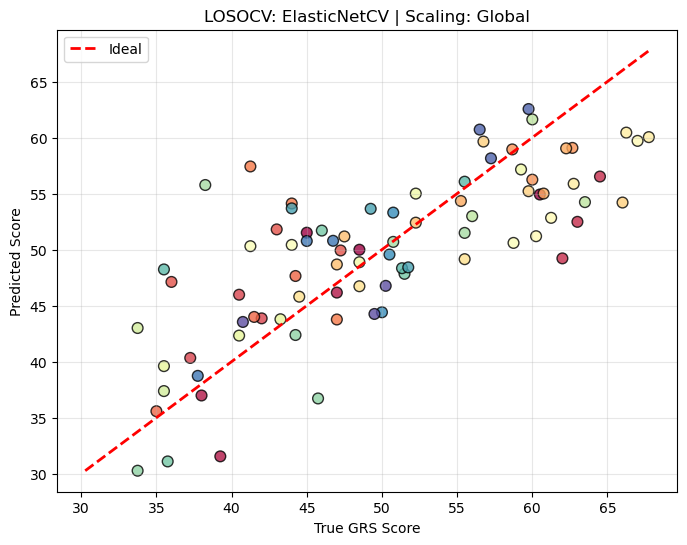

In [128]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

_, _, _ = evaluate_loso_model(df_combined, top_features_right, model_class=ElasticNetCV, model_params={'alphas': np.logspace(-2, 1, 20)},extra_features=candidate_features, print_fold_metrics=True, pca_components=[0])

## **BoW**

**Need to scale features before k-means clustering**

- First do it with a little data leakage
- But for the final results need to do this within each fold!



note this could be optimized by using more adequate clustering (for heavy tailed distributions do if I have time and what to write about this in detail in my thesis)

Adequate Clustering for Power-Law Kinematics
Standard K-means is often poor for power-law data because squared Euclidean distances are overly sensitive to the extreme values in features like dim_jerk or vel_p90. 

3. Creating "BoW-like" Kinematic Embeddings
If you want embeddings that function like BoW but handle your specific feature set:
Normalization is Mandatory: Use a Robust Scaler (based on medians and quartiles) rather than a Standard Scaler to prevent power-law outliers from squashing your other data.
Log-Transform: For features like dim_jerk and palm_area_cv, applying a log transformation can pull the long tail in, making them more suitable for clustering.
Fisher Vectors: Instead of a simple BoW histogram, use Fisher Vectors to encode the first and second-order statistics (means and variances) of your kinematic clusters. This provides a much richer "embedding" than simple frequency counts. 

In [129]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:06<00:00,  1.24it/s]


In [130]:
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer, PowerTransformer
import numpy as np

def prepare_clustering_data(df_windows, feature_cols, method='log', clip=5.0):
    """
    Prepares kinematic data for K-Means clustering.
    
    Methods:
        'log': Original np.log1p approach.
        'sqrt': Square root transform (medium-strength tail compression).
        'quantile': Forces a uniform or normal distribution (removes skew entirely).
        'yeo-johnson': Parametric power transform to minimize skewness.
    """
    X = df_windows[feature_cols].copy()
    
    # Identify skewed targets
    skew_targets = [c for c in feature_cols if any(x == c for x in ['dim_jerk', 'curvature', 'path_ratio', 'spatial_spread', 'vel_mean', 'palm_area_cv', 'ang_vel_mean', 'vel_p90'])]
    
    # 1. Apply Primary Transform
    if method == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif method == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif method == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif method == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    # 2. Scaling
    # Using RobustScaler followed by StandardScaler is the "gold standard" for K-means
    # as it centers the data while remaining resistant to extreme window artifacts.
    #scaler = StandardScaler()
    scaler = RobustScaler()  # Uncomment this line to use RobustScaler instead of StandardScaler
    X_scaled = scaler.fit_transform(X)
    
    # 3. Clipping
    # A clip of 10.0 is very wide for a Z-scored distribution (10 standard deviations).
    # Standard practice is usually 3.0 or 5.0 to ensure outliers don't pull centroids.
    X_scaled = np.clip(X_scaled, -clip, clip)
    
    return X_scaled, scaler


In [131]:
clip = 5.0
with_idle = False

if not with_idle:
    df = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df = df_window_features.copy()

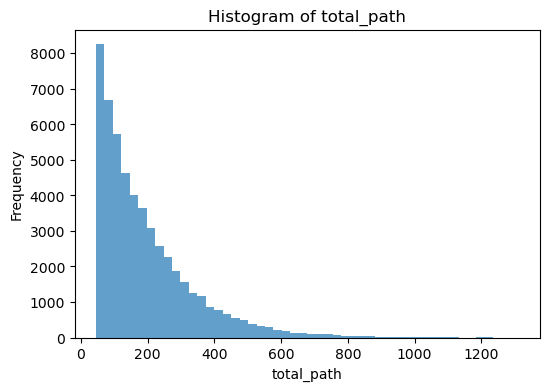

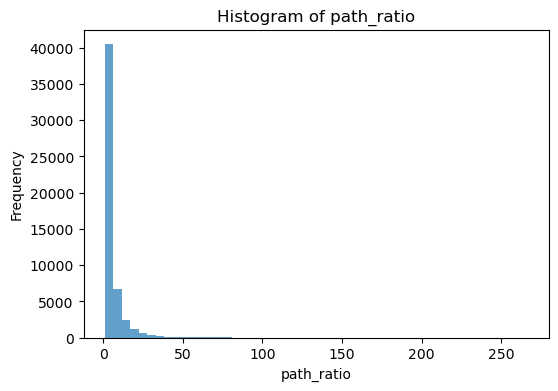

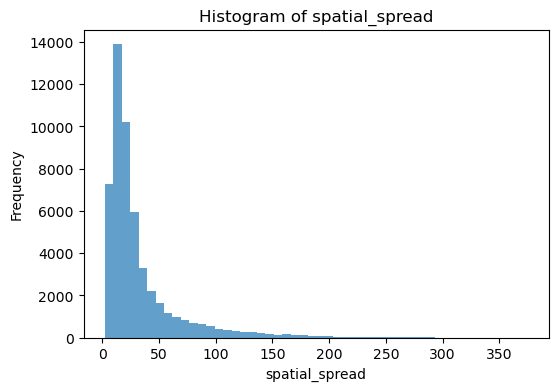

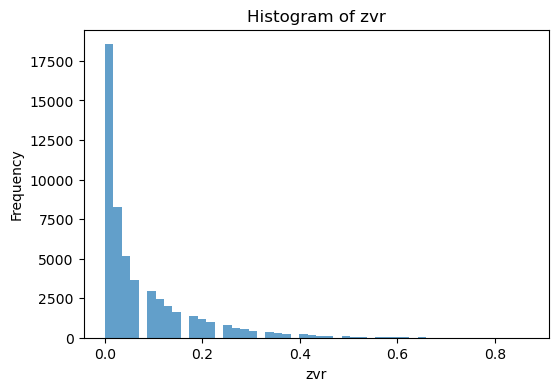

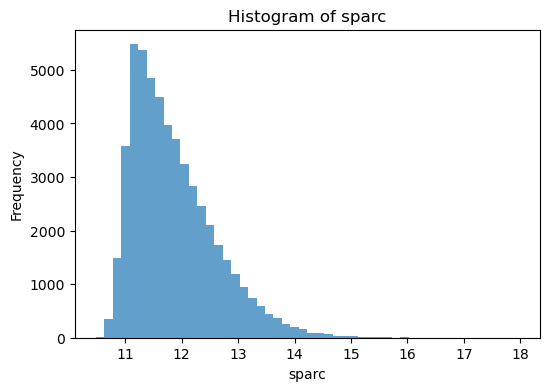

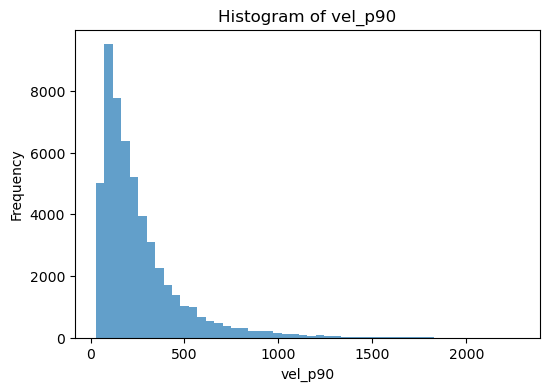

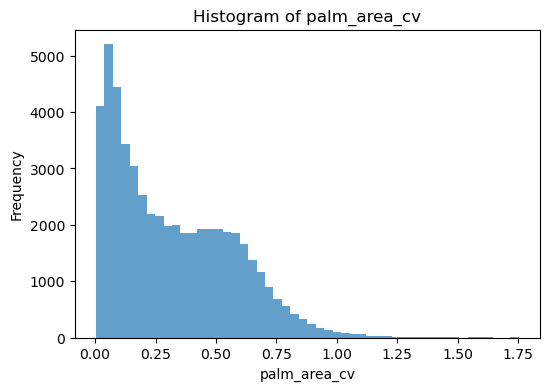

In [139]:
#hist of each feature
import matplotlib.pyplot as plt

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=50, alpha=0.7)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [140]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame', 'is_idle']]

# flip sign before log transform
#df['sparc'] = -df['sparc']

# Workflow
clustering_features = [col for col in df_window_features.columns if col in feature_cols]
X_for_km, scaler = prepare_clustering_data(df, clustering_features, method='log', clip=clip)
pd.DataFrame(X_for_km, columns=clustering_features).describe()

,total_path,path_ratio,spatial_spread,zvr,sparc,vel_p90,palm_area_cv
count,52428.000000,5.242800e+04,5.242800e+04,52428.000000,5.242800e+04,52428.000000,52428.000000
mean,0.257345,2.299760e-01,1.146586e-01,0.456275,1.627352e-01,0.020479,0.077959
std,0.869822,7.338368e-01,7.822905e-01,0.901140,7.498279e-01,0.689842,0.577219
min,-0.641553,-6.087902e-01,-1.873094e+00,-0.200000,-1.234336e+00,-1.778438,-0.752630
25%,-0.380284,-3.543949e-01,-4.400259e-01,-0.200000,-4.177782e-01,-0.509754,-0.448955
50%,0.000000,1.142343e-16,-2.238877e-16,0.000000,9.003410e-16,0.000000,0.000000
75%,0.619716,6.456051e-01,5.599741e-01,0.800000,5.822218e-01,0.490246,0.551045
max,5.000000,4.426517e+00,2.887267e+00,5.000000,5.000000e+00,2.363365,2.488896


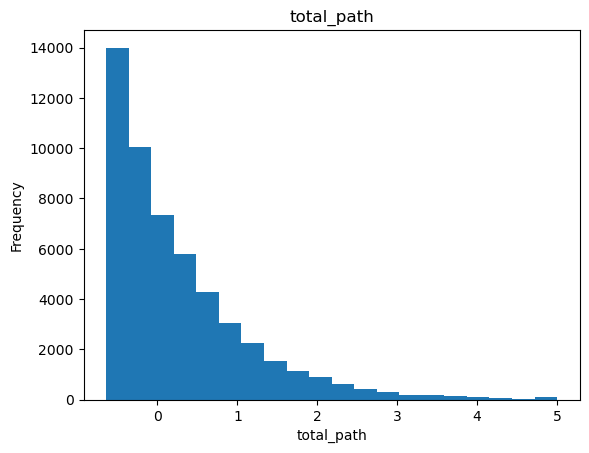

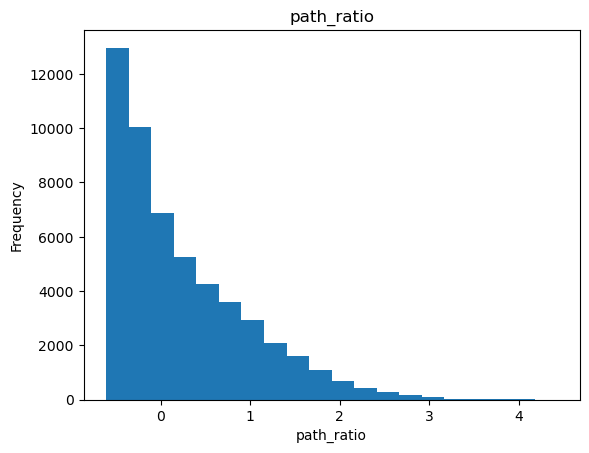

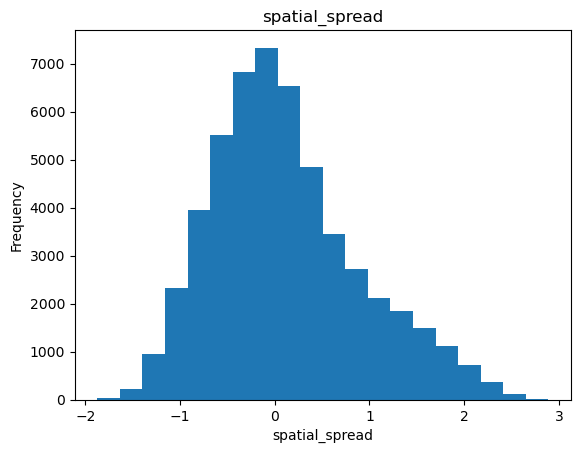

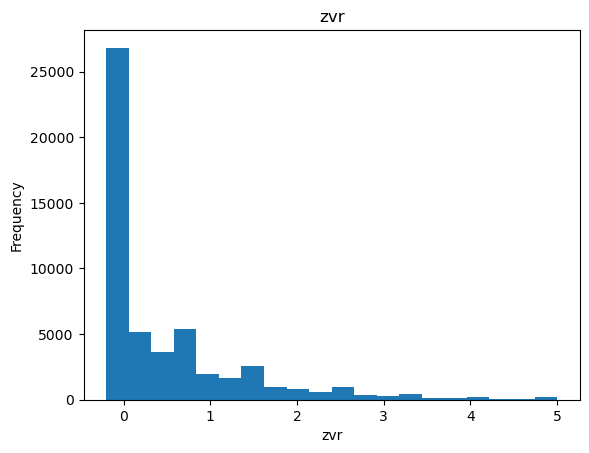

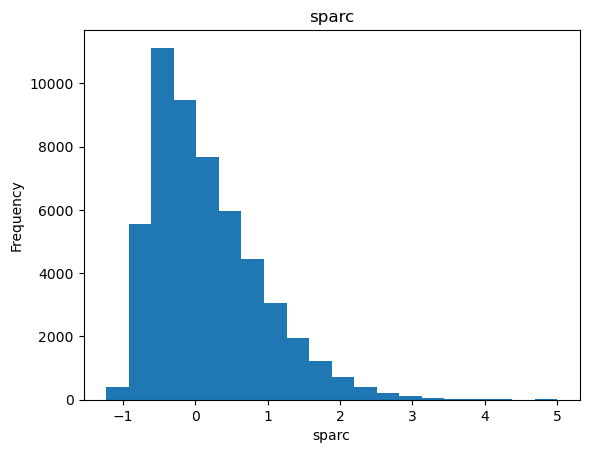

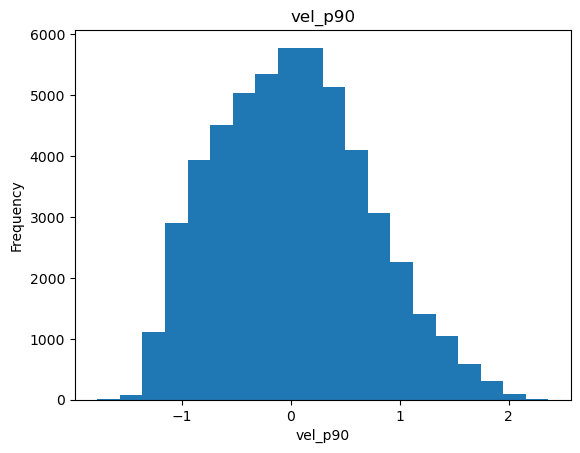

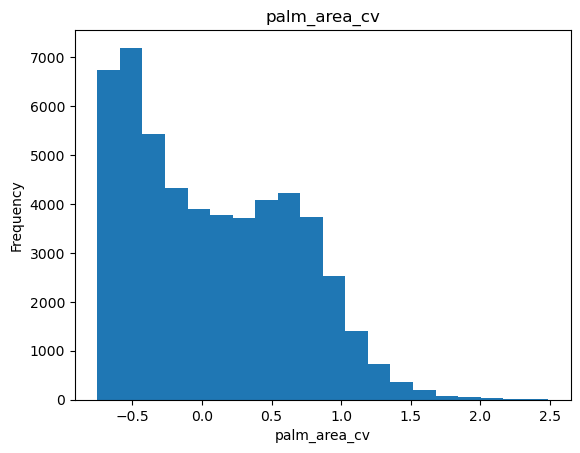

In [141]:
import matplotlib.pyplot as plt

for feat in clustering_features:
    plt.figure()
    pd.DataFrame(X_for_km, columns=clustering_features)[feat].plot(kind='hist', bins=20)
    plt.title(feat)
    plt.xlabel(feat)
    plt.ylabel("Frequency")
    plt.show()

In [143]:
feature_cols

['total_path',
 'path_ratio',
 'spatial_spread',
 'zvr',
 'sparc',
 'vel_p90',
 'palm_area_cv']

In [ ]:
# to move elsewhere later as function
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 16
RANDOM_STATE = 42
N_INIT = 5
METHOD = 'nothing'
skew_targets = [c for c in clustering_features if any(x == c for x in ['total_path', 'path_ratio', 'path_ratio', 'spatial_spread', 'zvr', 'sparc', 'vel_p90', 'palm_area_cv'])]

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
kmeans.fit(X_for_km)

bow_features = []

for vid, group in df.groupby('video_id'):
    
    X = group[clustering_features].copy()
    # 1. Apply Primary Transform
    if METHOD == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif METHOD == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif METHOD == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif METHOD == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    X_vid =  scaler.transform(X)
    X_vid = np.clip(X_vid, -clip, clip)
    cluster_labels = kmeans.predict(X_vid)
    
    # Build histogram
    hist, _ = np.histogram(cluster_labels, bins=np.arange(N_CLUSTERS + 1))
    hist = hist / np.sum(hist)  # Normalize to get proportions
    
    bow_features.append((vid, hist))

col_names = [f'BoW_{i}' for i in range(N_CLUSTERS)]
bow_df = pd.DataFrame([x[1] for x in bow_features], columns=col_names)  
bow_df['video_id'] = [x[0] for x in bow_features]   

bow_df[[col for col in bow_df.columns if col != 'video_id']].describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,BoW_10,BoW_11,BoW_12,BoW_13,BoW_14,BoW_15
count,83.0,83.0,83.000000,83.0,83.000000,83.0,83.000000,83.0,83.000000,83.000000,83.0,83.0,83.000000,83.0,83.000000,83.000000
mean,0.0,0.0,0.000401,0.0,0.183384,0.0,0.153814,0.0,0.001922,0.008052,0.0,0.0,0.652369,0.0,0.000025,0.000033
std,0.0,0.0,0.000851,0.0,0.063904,0.0,0.073040,0.0,0.002392,0.004885,0.0,0.0,0.087058,0.0,0.000231,0.000299
min,0.0,0.0,0.000000,0.0,0.071259,0.0,0.042500,0.0,0.000000,0.000000,0.0,0.0,0.371134,0.0,0.000000,0.000000
25%,0.0,0.0,0.000000,0.0,0.133880,0.0,0.103448,0.0,0.000000,0.004488,0.0,0.0,0.592597,0.0,0.000000,0.000000
50%,0.0,0.0,0.000000,0.0,0.175978,0.0,0.130909,0.0,0.001504,0.007194,0.0,0.0,0.669811,0.0,0.000000,0.000000
75%,0.0,0.0,0.000000,0.0,0.216345,0.0,0.185734,0.0,0.002546,0.010774,0.0,0.0,0.720523,0.0,0.000000,0.000000
max,0.0,0.0,0.003367,0.0,0.353222,0.0,0.429929,0.0,0.015789,0.023529,0.0,0.0,0.800676,0.0,0.002105,0.002725


In [71]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in bow_df.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = bow_df[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
BoW_0:        Pearson r = -0.5061, Spearman rho = -0.5018
BoW_12:        Pearson r = 0.3964, Spearman rho = 0.3608
BoW_11:        Pearson r = 0.3939, Spearman rho = 0.3739
BoW_10:        Pearson r = -0.3476, Spearman rho = -0.3200
BoW_5:        Pearson r = -0.3212, Spearman rho = -0.2945
BoW_8:        Pearson r = 0.2834, Spearman rho = 0.2205
BoW_4:        Pearson r = 0.2772, Spearman rho = 0.3084
BoW_7:        Pearson r = 0.2682, Spearman rho = 0.1996
BoW_9:        Pearson r = 0.2136, Spearman rho = 0.2652
BoW_6:        Pearson r = -0.2068, Spearman rho = -0.2650
BoW_15:        Pearson r = 0.1585, Spearman rho = 0.1312
BoW_13:        Pearson r = -0.1211, Spearman rho = -0.1823


In [72]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
centroids = kmeans.cluster_centers_
feature_names = clustering_features

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 0, (corr: -0.506): {'path_ratio': np.float64(-0.35), 'vel_mean': np.float64(-0.29), 'vel_p90': np.float64(-0.23), 'spatial_spread': np.float64(-0.09), 'palm_area_cv': np.float64(-0.8)}
Cluster 10, (corr: -0.348): {'path_ratio': np.float64(-0.28), 'vel_mean': np.float64(-0.83), 'vel_p90': np.float64(-0.75), 'spatial_spread': np.float64(-0.58), 'palm_area_cv': np.float64(-0.95)}
Cluster 5, (corr: -0.321): {'path_ratio': np.float64(-0.4), 'vel_mean': np.float64(0.57), 'vel_p90': np.float64(0.69), 'spatial_spread': np.float64(0.83), 'palm_area_cv': np.float64(-0.53)}
Cluster 6, (corr: -0.207): {'path_ratio': np.float64(-0.37), 'vel_mean': np.float64(0.92), 'vel_p90': np.float64(0.87), 'spatial_spread': np.float64(0.98), 'palm_area_cv': np.float64(0.97)}
Cluster 13, (corr: -0.121): {'path_ratio': np.float64(-0.4), 'vel_mean': np.float64(1.97), 'vel_p90': np.float64(2.03), 'spatial_spread': np.float64(2.18), 'palm_area_cv': np.float64(1.65)}

In [73]:
top_features = ['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right']

# load top feature df and combine with aggregated window features
comb_df = pd.merge(df_top_features, bow_df, left_index=True, right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, top_features, candidate_features, base_features=['velocity_corr'], top_n=1, perform_shuffle=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:01<00:00, 15.67it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
4,BoW_12,0.123663,0.011210,9.537604e-02,0.336473,0.785714
0,BoW_0,0.115386,0.015014,8.185755e-02,-0.311017,0.214286
8,BoW_2,0.066935,0.010247,4.040902e-02,-0.240449,0.000000
11,BoW_5,0.063424,0.011049,3.917861e-02,-0.242033,0.000000
14,BoW_8,0.061789,0.010119,4.079617e-02,0.244558,0.000000
7,BoW_15,0.036811,0.006515,2.148198e-02,0.181620,0.000000
3,BoW_11,0.019440,0.006098,7.708198e-03,0.123316,0.000000
2,BoW_10,0.017644,0.004661,1.046543e-02,-0.121990,0.000000
5,BoW_13,0.014498,0.004665,7.615549e-03,-0.118634,0.000000
13,BoW_7,0.012464,0.003909,4.434534e-03,0.106198,0.000000


In [59]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=comb_df,
    primary_features=top_features,
    candidate_features=candidate_features,
    extra_features=['velocity_corr'],
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=2,
    print_fold_metrics=True,
    corr_threshold=0.5,
    pr2_threshold=0.04
)

Surgeon 1 | Train MAE: 4.2902 | Test MAE: 7.7999 | Selected Features: ['BoW_11', 'BoW_3'] | Selected PR2s: [np.float64(0.0732), np.float64(0.066)]
Surgeon 2 | Train MAE: 4.5043 | Test MAE: 5.2286 | Selected Features: ['BoW_3', 'BoW_15'] | Selected PR2s: [np.float64(0.1018), np.float64(0.0754)]
Surgeon 3 | Train MAE: 4.4657 | Test MAE: 5.8178 | Selected Features: ['BoW_3', 'BoW_15'] | Selected PR2s: [np.float64(0.0933), np.float64(0.0731)]
Surgeon 4 | Train MAE: 4.4577 | Test MAE: 6.7805 | Selected Features: ['BoW_3', 'BoW_15'] | Selected PR2s: [np.float64(0.0736), np.float64(0.0689)]
Surgeon 5 | Train MAE: 4.4199 | Test MAE: 7.9591 | Selected Features: ['BoW_15', 'BoW_3'] | Selected PR2s: [np.float64(0.0928), np.float64(0.0921)]
Surgeon 6 | Train MAE: 4.6509 | Test MAE: 0.9655 | Selected Features: ['BoW_3', 'BoW_15'] | Selected PR2s: [np.float64(0.0859), np.float64(0.0722)]
Surgeon 7 | Train MAE: 4.4378 | Test MAE: 6.6862 | Selected Features: ['BoW_3', 'BoW_15'] | Selected PR2s: [np.fl

### Significance Test 

In [ ]:
all_shuffled_r2 = []
all_shuffled_top_BoW = []

seeds = random.sample(range(0, 100), 25)
for seed in seeds:
    df_res = leakage_free_residual_analysis(comb_df, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    bow_6_r2 = df_res[df_res['Feature']=='BoW_7']['Shuffled_R2_mean'].values[0]
    all_shuffled_top_BoW.append(bow_6_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.87it/s]


Seed 12: Top 3 R2: [0.04406501 0.04169252 0.03497045]


Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  4.85it/s]


Seed 47: Top 3 R2: [0.03420142 0.02730518 0.0225491 ]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.71it/s]


...

Seed 62: Top 3 R2: [0.10098647 0.09899331 0.09154715]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.53it/s]


Seed 61: Top 3 R2: [0.04841938 0.04676928 0.04644585]


Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.34it/s]

Seed 36: Top 3 R2: [0.15946643 0.14011028 0.13101303]


Empirical p-value: 0.200
Z-score vs Null: 0.71


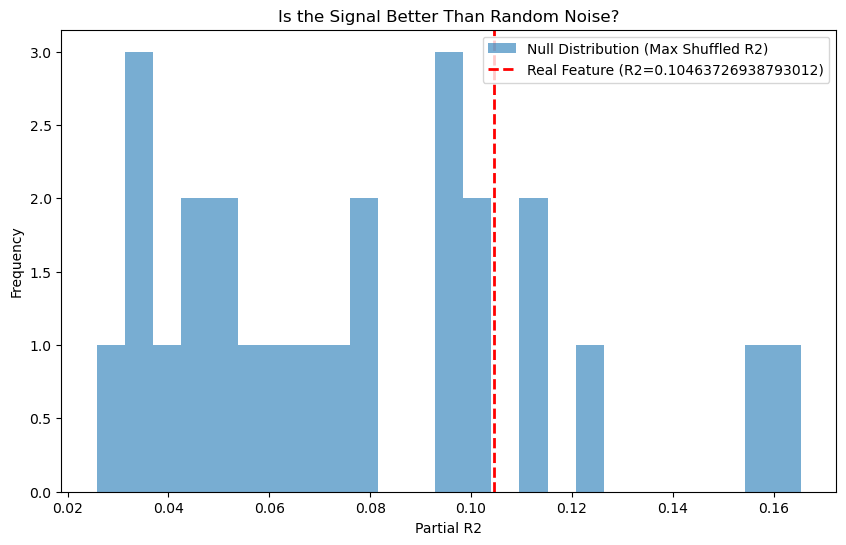

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.10463726938793012

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Does this confirm the need for MIL?**

Yes. univariate analysis has effectively "cleared the field." have proven that:

Individual local patterns (BoW bins) are just echoes of global efficiency.

The "Style" or "Technique" signal is not contained in the frequency of common movements.

This is the perfect lead-in for your Gated Attention MIL. The MIL head doesn't care about the frequency of "Fast" windows. It looks for co-occurrences and non-linear transitions. It might find that "Jerk" only matters when "Palm Area CV" is also high. That kind of interaction is something a univariate Partial R 
R2 test on a BoW bin will never see.

## **TO DO**
- Need To Make a Statistical Test
    to see if this approach is statistically significant to extract features.  
    i.e how probable is it that we get this high partial R2 in random scenario?

    - spatial spread is statistically strong enough in the shuffle test
    - palm_area_cv not, but with the correlation argument with skill scores maybe

    => solution that is easier to defend is probably to select features within folds directly.

- Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

- Do feature selection directly within LOSO loop, so leakage argument doesn't hold, with various features selection methods

- Do a hyperparameter search 